# Pembangunan dan Pelatihan Model untuk Fitur Kombinasi Obat

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

save_dir = '/content/drive/MyDrive/Project_Obat'
os.makedirs(save_dir, exist_ok=True)

model.save(os.path.join(save_dir, 'model_interaksi_obat.keras'))

## Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## Load Dataset

In [ ]:
df_ddi = pd.read_csv('Master_DDI_Dataset.csv')
df_inter = pd.read_csv('Master_Data_Interaksi_ID.csv')

print("Jumlah baris Master DDI:", df_ddi.shape)
print("Jumlah baris Master Interaksi ID:", df_inter.shape)

Jumlah baris Master DDI: (222127, 6)
Jumlah baris Master Interaksi ID: (104096, 8)


## Visualisasi Kelas

/tmp/ipykernel_710/2060185279.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(x=top_classes.index.astype(str), y=top_classes.values, palette='Blues_r')
/tmp/ipykernel_710/2060185279.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x=interaction_counts.index, y=interaction_counts.values, palette='viridis')


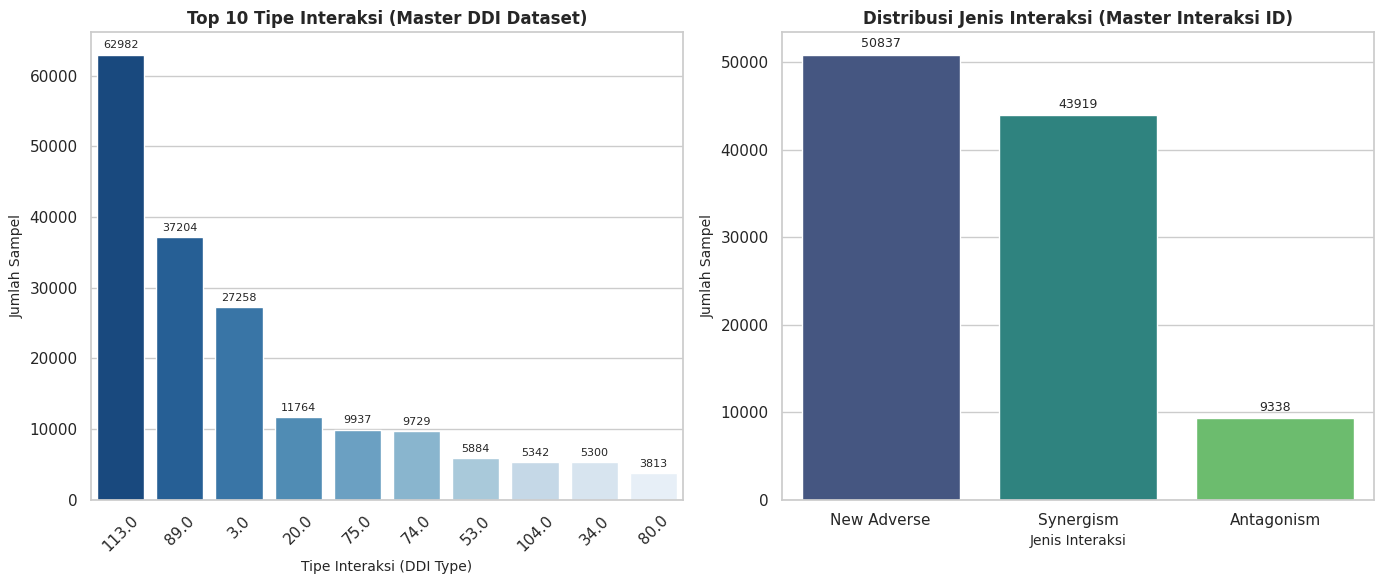

In [ ]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
top_classes = df_ddi['DDI type'].value_counts().head(10)
ax1 = sns.barplot(x=top_classes.index.astype(str), y=top_classes.values, palette='Blues_r')
plt.title('Top 10 Tipe Interaksi (Master DDI Dataset)', fontsize=12, fontweight='bold')
plt.xlabel('Tipe Interaksi (DDI Type)', fontsize=10)
plt.ylabel('Jumlah Sampel', fontsize=10)
plt.xticks(rotation=45)

for p in ax1.patches:
    ax1.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=8, xytext=(0, 3),
                 textcoords='offset points')

plt.subplot(1, 2, 2)
interaction_counts = df_inter['Interaction'].value_counts()
ax2 = sns.barplot(x=interaction_counts.index, y=interaction_counts.values, palette='viridis')
plt.title('Distribusi Jenis Interaksi (Master Interaksi ID)', fontsize=12, fontweight='bold')
plt.xlabel('Jenis Interaksi', fontsize=10)
plt.ylabel('Jumlah Sampel', fontsize=10)

for p in ax2.patches:
    ax2.annotate(f'{int(p.get_height())}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                 textcoords='offset points')

plt.tight_layout()
plt.show()

## Dataset Preparation

In [ ]:
texts_ddi = df_ddi['Interaction description'].astype(str).values
labels_ddi = df_ddi['DDI type'].values

In [ ]:
df_inter['Adverse Effects'] = df_inter['Adverse Effects'].fillna('No adverse effect specified')
texts_inter = (
    "Interaction between " + df_inter['Name_Drug1'].fillna('Unknown') +
    " and " + df_inter['Name_Drug2'].fillna('Unknown') +
    " shows " + df_inter['Interaction'].astype(str) +
    " with effects: " + df_inter['Adverse Effects'].astype(str)
).values
labels_inter = df_inter['Interaction'].astype(str).values

In [ ]:
X_raw = np.concatenate([texts_ddi, texts_inter])
y_raw = np.concatenate([labels_ddi.astype(str), labels_inter])

In [ ]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_raw)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Total keseluruhan data: {len(X_raw)}")
print(f"Jumlah Data Train: {len(X_train)}")
print(f"Jumlah Data Test: {len(X_test)}")
print(f"Total Kelas (Classes): {len(np.unique(y_encoded))}")

Total keseluruhan data: 326223
Jumlah Data Train: 260978
Jumlah Data Test: 65245
Total Kelas (Classes): 112


## Preprocessing Dataset

### Tokenize Dataset

In [ ]:
vocab_size = 10000
max_length = 1200
trunc_type = 'post'
padding_type = 'post'
oov_tok = "<OOV>"

### Convert text to Sequence

In [ ]:
tokenizer = Tokenizer(num_words=vocab_size, oov_token=oov_tok)
tokenizer.fit_on_texts(X_train)

train_sequences = tokenizer.texts_to_sequences(X_train)
test_sequences = tokenizer.texts_to_sequences(X_test)

### Padding

In [ ]:
train_padded = pad_sequences(train_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)
test_padded = pad_sequences(test_sequences, maxlen=max_length, padding=padding_type, truncating=trunc_type)

print("Shape Training Data Padded:", train_padded.shape)
print("Shape Testing Data Padded:", test_padded.shape)

Shape Training Data Padded: (260978, 1200)
Shape Testing Data Padded: (65245, 1200)


## BiLSTM Model

In [ ]:
num_classes = len(np.unique(y_encoded))
vocab_size = 10000
max_length = 1200
embedding_dim = 64

### Arsitektur Model

In [ ]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=max_length),

    Bidirectional(LSTM(64, return_sequences=True)),
    Dropout(0.3),

    Bidirectional(LSTM(32)),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.3),

    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


### Compile Model

In [ ]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

### Summary

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Callbacks

### Checkpoint Callback

In [ ]:
checkpoint_callback = ModelCheckpoint(
    filepath='best_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

### Membangun Callback

In [ ]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

callbacks_list = [checkpoint_callback, early_stopping]

## Training

In [ ]:
num_epochs = 10
batch_size = 64

print("Memulai proses training...")
history = model.fit(
    train_padded, y_train,
    epochs=num_epochs,
    batch_size=batch_size,
    validation_data=(test_padded, y_test),
    callbacks=callbacks_list,
    verbose=1
)
print("Training selesai")

Memulai proses training...
Epoch 1/10
4078/4078 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - accuracy: 0.8088 - loss: 0.8025
Epoch 1: val_accuracy improved from None to 0.98516, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
4078/4078 ━━━━━━━━━━━━━━━━━━━━ 624s 151ms/step - accuracy: 0.9041 - loss: 0.3791 - val_accuracy: 0.9852 - val_loss: 0.0628
Epoch 2/10
4078/4078 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.9765 - loss: 0.0866
Epoch 2: val_accuracy improved from 0.98516 to 0.99565, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
4078/4078 ━━━━━━━━━━━━━━━━━━━━ 620s 152ms/step - accuracy: 0.9809 - loss: 0.0691 - val_accuracy: 0.9956 - val_loss: 0.0186
Epoch 3/10
4078/4078 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.9878 - loss: 0.0425
Epoch 3: val_accuracy improved from 0.99565 to 0.99773, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
4078/4078 ━━━━━━━━━━━━━━━━━━━━ 618s 1

## Evaluation

### Initial & Tes Evaluation

In [ ]:
loss, accuracy = model.evaluate(test_padded, y_test, verbose=1)
print(f"\nEvaluasi Model pada Data Test:")
print(f"Loss     : {loss:.4f}")
print(f"Akurasi  : {accuracy * 100:.2f}%")

2039/2039 ━━━━━━━━━━━━━━━━━━━━ 121s 59ms/step - accuracy: 0.9997 - loss: 0.0013

Evaluasi Model pada Data Test:
Loss     : 0.0013
Akurasi  : 99.97%


### Data Testing Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred_probs = model.predict(test_padded)

y_pred = np.argmax(y_pred_probs, axis=1)

print("DATA TESTING CLASSIFICATION REPORT\n")
print(classification_report(y_test, y_pred, zero_division=0))

2039/2039 ━━━━━━━━━━━━━━━━━━━━ 116s 57ms/step
DATA TESTING CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.46      1.00      0.63         6
           1       1.00      1.00      1.00       564
           2       1.00      0.93      0.96        14
           3       0.00      0.00      0.00         1
           4       1.00      1.00      1.00         4
           5       1.00      1.00      1.00        98
           6       1.00      1.00      1.00      1068
           7       1.00      1.00      1.00       167
           8       0.78      1.00      0.88         7
           9       1.00      1.00      1.00         4
          10       1.00      1.00      1.00       365
          11       1.00      1.00      1.00       290
          12       1.00      1.00      1.00       215
          13       1.00      1.00      1.00         5
          14       1.00      1.00      1.00        26
          15       0.33      1.00      0.50         2

### Plotting Akurasi & Loss

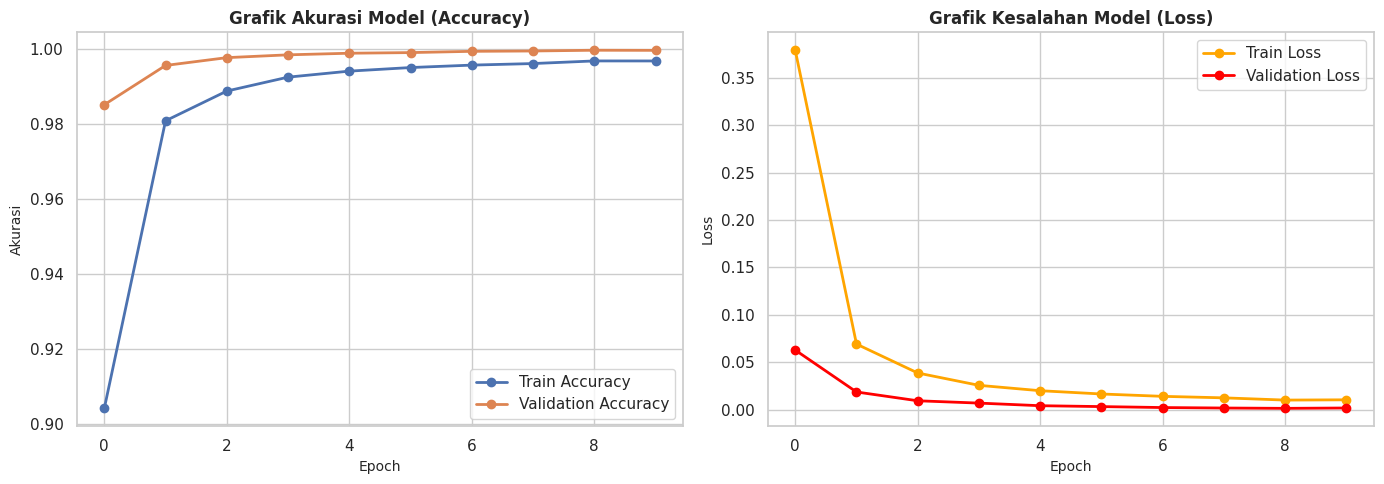

In [ ]:
plt.figure(figsize=(14, 5))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, marker='o')
plt.title('Grafik Akurasi Model (Accuracy)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Akurasi', fontsize=10)
plt.legend()
plt.grid(True)

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2, marker='o', color='orange')
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, marker='o', color='red')
plt.title('Grafik Kesalahan Model (Loss)', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=10)
plt.ylabel('Loss', fontsize=10)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Inference

In [ ]:
def get_detailed_report_fixed(nama_obat_a, nama_obat_b):
    match_ddi = df_ddi[
        (df_ddi['Drug A'].str.lower() == nama_obat_a.lower()) &
        (df_ddi['Drug B'].str.lower() == nama_obat_b.lower())
    ]

    if match_ddi.empty:
        match_ddi = df_ddi[
            (df_ddi['Drug A'].str.lower() == nama_obat_b.lower()) &
            (df_ddi['Drug B'].str.lower() == nama_obat_a.lower())
        ]

    if not match_ddi.empty:
        interaction_desc = match_ddi['Interaction description'].values[0]

        desc_lower = interaction_desc.lower()
        if any(keyword in desc_lower for keyword in ['heart failure', 'hypotension', 'increased', 'severity', 'risk', 'congestive']):
            urgency_label = "🔴 - HIGH (CONTRAINDICATION)"
            summary_text = "Dangerous interaction! Significant clinical risk to the patient."
        else:
            urgency_label = "🟡 - SEDANG"
            summary_text = "The interaction requires clinical monitoring."
    else:
        interaction_desc = "Deskripsi tidak ditemukan secara langsung di dataset DDI."
        urgency_label = "🟢 - AMAN / TIDAK ADA DATA SIGNIFIKAN"
        summary_text = "Tidak ditemukan catatan interaksi mayor."

    desc_a, desc_b = "Data not available", "Data not available"

    match_info_a = df_inter[df_inter['Name_Drug1'].str.lower() == nama_obat_a.lower()]
    if not match_info_a.empty and pd.notna(match_info_a['Desc_Drug1'].values[0]):
        desc_a = match_info_a['Desc_Drug1'].values[0]

    match_info_b = df_inter[df_inter['Name_Drug2'].str.lower() == nama_obat_b.lower()]
    if not match_info_b.empty and pd.notna(match_info_b['Desc_Drug2'].values[0]):
        desc_b = match_info_b['Desc_Drug2'].values[0]

    efek_samping_teks = interaction_desc if not match_ddi.empty else "There is no specific data."

    print("==================================================")
    print("           CLINICAL REPORT OF DRUG ")
    print("==================================================")
    print(f"Drug Pair        : {nama_obat_a.upper()} & {nama_obat_b.upper()}")
    print(f"Level of Urgency : {urgency_label}")
    print(f"Quick Summary    : {summary_text}")
    print(f"Risk             : {interaction_desc}")
    print("\n--------------------------------------------------")
    print(f"--- MEDICATION DETAILS: {nama_obat_a.upper()} ---")
    print(f"Utility     : {desc_a[:110]}...")
    print("\n--------------------------------------------------")
    print(f"--- MEDICATION DETAILS: {nama_obat_b.upper()} ---")
    print(f"Utility     : {desc_b[:110]}...")
    print("==================================================")

get_detailed_report_fixed("Nifedipine", "Esmolol")

       LAPORAN KLINIS OBAT 
Pasangan Obat   : NIFEDIPINE & ESMOLOL
Tingkat Urgensi : 🔴 - TINGGI (KONTRAINDIKASI)
Ringkasan Cepat : Interaksi berbahaya! Risiko klinis signifikan terhadap pasien.
Resiko          : The risk or severity of congestive heart failure and hypotension can be increased when Nifedipine is combined with Esmolol.

--------------------------------------------------
--- DETAIL OBAT: NIFEDIPINE ---
Kegunaan    : Nifedipine, or BAY a 1040, is a first generation dihydropyridine L-type calcium channel blocker, similar to [n...

--------------------------------------------------
--- DETAIL OBAT: ESMOLOL ---
Kegunaan    : Esmolol, commonly marketed under the trade name Brevibloc, is a cardioselective beta-1 receptor blocker. It ha...


## Save Model

In [ ]:
import pickle
import os
import pandas as pd

print("Menyimpan komponen sistem...")

persist_directory = "./chroma_db_dir"

print(f"Vector Database tersimpan di direktori: {persist_directory}")

drug1_info = df_inter[['Name_Drug1', 'Desc_Drug1']].rename(columns={'Name_Drug1': 'drug_name', 'Desc_Drug1': 'description'})

drug2_info = df_inter[['Name_Drug2', 'Desc_Drug2']].rename(columns={'Name_Drug2': 'drug_name', 'Desc_Drug2': 'description'})

df_info = pd.concat([drug1_info, drug2_info]).dropna(subset=['drug_name']).drop_duplicates(subset=['drug_name']).reset_index(drop=True)

drug_info_dict = df_info.set_index('drug_name')['description'].to_dict()

with open('drug_info_dict.pkl', 'wb') as f:
    pickle.dump(drug_info_dict, f)

df_ddi.to_pickle('df_ddi.pkl')
df_info.to_pickle('df_info.pkl')

print("Semua komponen model dan dataset berhasil disimpan!")

Menyimpan komponen sistem...
Vector Database tersimpan di direktori: ./chroma_db_dir
Semua komponen model dan dataset berhasil disimpan!


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(10,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.save('model_interaksi_obat.keras')
print("Model berhasil disimpan sebagai 'model_interaksi_obat.keras'")

Model berhasil disimpan sebagai 'model_interaksi_obat.keras'


In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model('model_interaksi_obat.keras')
print("Model .keras berhasil dimuat dan siap digunakan untuk prediksi!")

Model .keras berhasil dimuat dan siap digunakan untuk prediksi!


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 14 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))
